# Degeneracy and White Dwarfs

## Distribution function

The distribution function describes the properties of the electrons, and has the following meaning: $n(p) d^3 x d^3 p$ is the number of particles with momentum $p$ in a volume $d^3x$.  Our distribution function is:


$$n(p) = \frac{2}{h^3} \frac{1}{e^{\mathcal{E}(p)/{k_B T} - \eta} + 1}$$

where $\mathcal{E}$ is the kinetic energy of the electron, $T$ is the temperature, and $\eta$ is the _degeneracy parameter_ which is related to the chemical potential, $\mu$, and the [Fermi energy](https://en.wikipedia.org/wiki/Fermi_energy), $\mathcal{E}_F$, as:

$$\eta = \frac{\mu - m_e c^2}{k_B T} = \frac{\mathcal{E}_F}{k_B T}$$

## Degeneracy

The electrons are degenerate when $\eta \gg 1$, which means that the Fermi energy is much greater than the thermal energy.  The electrons behave as an ideal gas when $-\eta \gg 1$ (in this case, the $+1$ in the denominator of $n(p)$ is insignificant and we get the Maxwell-Boltzmann distribution).

To get the _number density_, we integrate over all momenta:

$$n = \int n(p) d^3 p$$

The pressure and specific internal energy, $e$, are then found as:

$$P = \frac{1}{3} \int n(p) v(p) p d^3 p$$
$$\rho e = \int n(p) \mathcal{E}(p) d^3 p$$

## Transition to degeneracy

Let's look at the behavior of the distribution function.  Consider:

$$F(\mathcal{E}) = \frac{1}{e^{\mathcal{E}/k_B T - \eta} + 1}$$

let's define

$$\xi \equiv \frac{\mathcal{E}}{k_B T}$$

then we have

$$F(\xi) = \frac{1}{e^{\xi - \eta} + 1}$$

and for each choice of $\eta$ we have a unique distribution.

We note that $\xi/\eta = \mathcal{E}/\mathcal{E}_F$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def F(xi, eta=100):
    return 1.0 / (np.exp(xi - eta) + 1)

Let's look at the case of $\eta > 1$

Text(0.5, 0, '$\\mathcal{E}/\\mathcal{E}_F$')

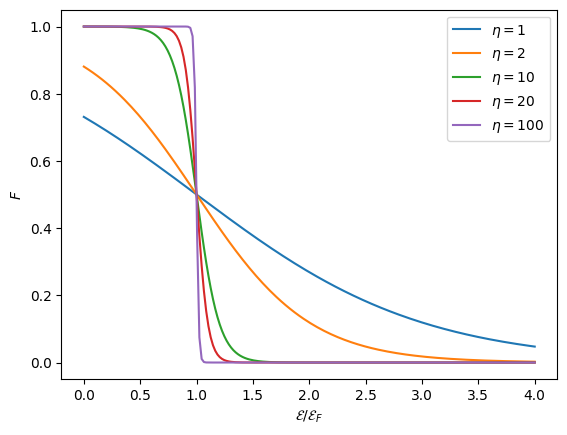

In [4]:
fig, ax = plt.subplots()

# we'll work in terms of r = xi / eta
r = np.linspace(0, 4, 200)

for eta in [1, 2, 10, 20, 100]:
    ax.plot(r, F(eta * r, eta=eta), label=fr"$\eta = {eta}$")
    
ax.legend()
ax.set_ylabel("$F$")
ax.set_xlabel(r"$\mathcal{E}/\mathcal{E}_F$")

As we see, as $\eta \rightarrow \infty$, the distribution, $F(\mathcal{E})$ becomes a step function.  This is the limit of complete degeneracy, and we have:

$$F(\mathcal{E}) = \left \{ \begin{array}{cc} 1 & \mathcal{E} < \mathcal{E}_F \\
                                              0 & \mathcal{E} > \mathcal{E}_F \end{array} \right .$$

We can alternately use the Fermi momentum, $p_F$ to describe the location of the step.

With this form, the integral for number density is trivial:

$$n_e = \frac{8\pi}{h^3} \int_0^{\mathcal{p}_F} p^2 dp$$

where we switched to spherical coordinates in momentum space: $d^3p \rightarrow 4\pi p^2 dp$.

## Computing $\eta$

For other values of $\eta$, we have a problem:

$$n_e = \frac{8\pi}{h^3} \int_0^\infty \frac{p^2}{e^{\mathcal{E}(p)/k_B T - \eta} + 1} dp$$

We don't know what the value of $\eta$ is ahead of time.  Instead, we typically know what the density of the star is, and we can find the
number density of electrons as:

$$n_e = \frac{\rho Y_e}{m_u}$$

where $Y_e$ is the electron fraction (typically around $1/2$ for compositions heavier than hydrogen).  This means that given $\rho, T$,
we can solve for $\eta$.


The kinetic energy of a particle can be found from the relativisitic expression:

$$\mathcal{E}(p) = m_e c^2 \left [ \sqrt{1 + \left ( \frac{p}{m_e c} \right )^2 } - 1 \right ]$$

```{note}
This has the proper limit in the non-relativistic case, $|p| \ll m_e c$:

$$\mathcal{E} = \frac{p^2}{2m_e}$$

Once we have $\eta$, we can then find the pressure and energy of the gas.

## Finding the trend of $\eta$ with $\rho, T$


In [6]:
import pynucastro as pyna

In [8]:
eos = pyna.eos.ElectronEOS()

In [9]:
import numpy as np

In [10]:
comp = pyna.Composition(["o16", "ne20"])
comp.set_equal()

In [11]:
rhos = np.logspace(0, 7, 75)

etas = {}
for T in [1.e6, 1.e7, 1.e8]:
    etas[T] = []
    for rho in rhos:
        ee, pe = eos.pe_state(rho, T, comp)
        etas[T].append(ee.eta)

In [13]:
import matplotlib.pyplot as plt

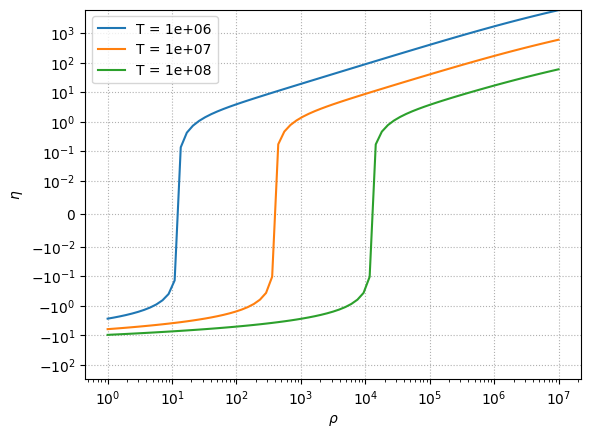

In [17]:
fig, ax = plt.subplots()

for T in etas:
    ax.plot(rhos, etas[T], label=f"T = {T:5.2g}")

ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$\eta$")
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1.e-2)
ax.legend()
ax.grid(ls=":")